In [1]:
import os

os.environ["CUDA_VISIBLE_DEVICES"] = "1"
os.environ["XLA_PYTHON_CLIENT_PREALLOCATE"] = "false"

import jax
import jax.numpy as jnp
import numpy as np
import matplotlib.pyplot as plt
from jax import grad, vmap, random
import optax
import diffrax
from seaborn import kdeplot
from ot.sliced import sliced_wasserstein_distance as swd

from triangular_transport.flows.flow_trainer import (
    NNTrainer,
)

from triangular_transport.flows.interpolants import (
    linear_interpolant,
    linear_interpolant_der,
    trig_interpolant,
    trig_interpolant_der,
    sigmoid_interpolant,
    sigmoid_interpolant_der
)
from triangular_transport.flows.loss_functions import vec_field_loss
from triangular_transport.networks.flow_networks import MLP
from triangular_transport.flows.dataloaders import log_normal_reference_sampler
from triangular_transport.flows.methods.plotting import plot_matrix
from triangular_transport.flows.methods.utils import UnitGaussianNormalizer
jax.config.update("jax_enable_x64", True)

plt.style.use("ggplot")

In [2]:
train_data = np.load("training_data.npy")
T = 18
u_dim = 4
yu_dimension = (T, u_dim)

ys, us = train_data[:, :T], train_data[:, T:]
ys_normalizer, us_normalizer = UnitGaussianNormalizer(ys), UnitGaussianNormalizer(us)
ysn, usn = ys_normalizer.encode(), us_normalizer.encode()
x1_data = jnp.hstack([ysn, usn])

In [3]:
ys_normalizer, us_normalizer = UnitGaussianNormalizer(ys), UnitGaussianNormalizer(us)
ysn, usn = ys_normalizer.encode(), us_normalizer.encode()
x1_data = jnp.hstack([ysn, usn])

T = 18
u_dim = 4
yu_dimension = (T, u_dim)

In [4]:
key = random.PRNGKey(1)
key, key1, key2, key3, key4 = random.split(key, 5)
key, subkey1 = random.split(key, 2)
u0s = log_normal_reference_sampler(
    key=key2, 
    shape=(x1_data.shape[0], u_dim), 
    mu=jnp.array([-0.125, -3.0, -0.125, -3.0]), 
    sigma=1 / jnp.sqrt(2)
)
u0sn = us_normalizer.encode(u0s)
x0_data = jnp.hstack([ysn, u0sn])

In [5]:
epochs = 100
train_dim = x1_data.shape[0]
batch_size = 2048
batch_size = min(batch_size, train_dim)
batch_size -= 1
steps_per_epoch = int(np.ceil(train_dim / batch_size))
steps = steps_per_epoch * epochs

In [ ]:
train_dim = x1_data.shape[0]
print_every = 5000
dim = T + u_dim
hidden_layer_list = [400] * 6
# hidden_layer_list = [400] * 3
model = MLP(
    key=key2,
    dim=dim,
    time_varying=True,
    w=hidden_layer_list,
    num_layers=len(hidden_layer_list) + 1,
    activation_fn=jax.nn.gelu,  # GeLU worked well
)
# schedule = optax.exponential_decay(
#     init_value=1e-2,
#     transition_steps=1000,
#     decay_rate=0.9,
#     staircase=True,
# )
schedule = optax.warmup_cosine_decay_schedule(
    init_value=0.0,
    peak_value=1e-3,
    warmup_steps=400,
    decay_steps=steps,
    end_value=1e-5,
)
optimizer = optax.adamw(schedule)
yu_dimension = (18, 4)

interpolant = linear_interpolant
interpolant_der = linear_interpolant_der
interpolant_args = {"t": None, "x1": None, "x0": None}
reference_sampler_args = {
    "mu": jnp.array([-0.125, -3.0, -0.125, -3.0]),
    "sigma": 1 / jnp.sqrt(2),
    "normalizer": us_normalizer,
}

In [7]:
trainer = NNTrainer(
    target_density=None,
    model=model,
    optimizer=optimizer,
    interpolant=interpolant,
    interpolant_der=interpolant_der,
    reference_sampler=log_normal_reference_sampler,
    reference_sampler_args=reference_sampler_args,
    loss=vec_field_loss,
    interpolant_args=interpolant_args,
    yu_dimension=yu_dimension,
    t_sampler=None,
)

trainer.train(
    train_data=x1_data,
    train_dim=train_dim,
    batch_size=batch_size,
    steps=steps,
    x0_data=None,
    print_every=print_every,
);

Training neural network


  0%|          | 0/4900 [00:00<?, ?it/s]

step = 0, train_loss = 0.021212231513302118
step = 4899, train_loss = -5.659167451687324


In [18]:
nsamples = 20000
# yobs = np.exp(np.load("true_samps/y_obs.npy")) # Original is in log space
# yobs = np.load("true_samps/y_moderate.npy")
# yobs = ys[np.random.choice(len(ys))]
# rng = np.random.RandomState(42)
# yobs = yobs + 0.001 * rng.randn(yobs.shape[0],)
# yobs = ys[4]
# yobs = np.exp(np.load("true_samps/y_obs.npy"))
cond_vals = [np.exp(np.load("true_samps/y_obs.npy")), np.load("true_samps/y_moderate.npy"), np.load("true_samps/y_rare.npy")]
ncond_vals = [ys_normalizer.encode(yobs) for yobs in cond_vals]
# yobsn = ys_normalizer.encode(yobs)
solver_args = {"solver": diffrax.Dopri5(), "max_steps": 50000, "stepsize_controller": diffrax.PIDController(rtol=1e-4, atol=1e-6)}
cond_samples = trainer.conditional_sample(
    cond_values=ncond_vals,
    nsamples=nsamples,
    u0_cond=None,
    solver_args=solver_args,
)

  0%|          | 0/3 [00:00<?, ?it/s]

In [11]:
len(cond_samples)

3

In [25]:
usn_gen = cond_samples[1][:, T:]
us_gen = us_normalizer.decode(usn_gen)
us_mean = jnp.mean(us_gen, axis=0)

# u_true = jnp.array([0.83194674, 0.04134147, 1.0823151, 0.03991483])

In [26]:
u_moderate = np.array([1.0251955 , 0.02654782, 1.1242096 , 0.2028351 ])
u_rare = np.array([0.442866  , 0.03737646, 0.13543342, 0.03316975])
u_true = jnp.array([0.83194674, 0.04134147, 1.0823151, 0.03991483])

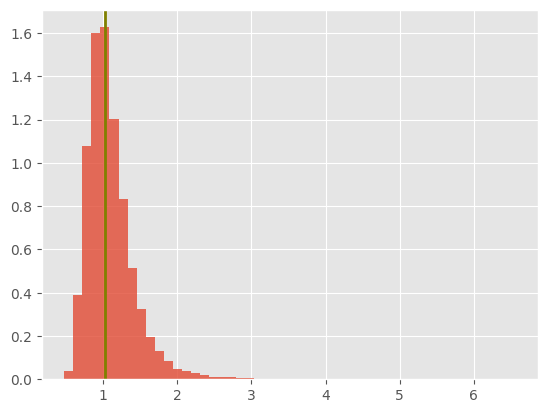

In [34]:
plt.hist(us_gen[:, 0], bins=50, alpha=0.8, density=True);
plt.axvline(u_moderate[0], c="olive", linewidth=2)

In [64]:
us_mean

Array([0.57937044, 0.09335947, 0.2074512 , 0.08864731], dtype=float64)

In [21]:
us[4]

Array([0.67115427, 0.02268814, 0.59830355, 0.01951158], dtype=float64)

Test variance of SWD

In [87]:
import numpy as np
import matplotlib.pyplot as plt
plt.style.use("ggplot")

In [143]:
# us_true = np.load("true_samps/true_us_rare_obs_3.npy")[::10, :]
# us_true = np.load("true_samps/true_us_obs.npy")[::10, :]
us_true = np.load("true_samps/true_us_moderate_obs_2.npy")[::10, :]
# true_us3 = np.load("true_samps/true_us_moderate_obs_3.npy")[::20, :]
# true_us4 = np.load("true_samps/true_us_moderate_obs_4.npy")[::20, :]

# us_true = np.exp(np.vstack([true_us1, true_us2, true_us3]))
np.random.shuffle(us_true)
us_true = np.exp(us_true)

In [144]:
np.mean(us_true, axis=0)

array([3.18745725, 0.06000673, 0.90510168, 0.0329097 ])

In [145]:
np.mean(np.exp(us_ada), axis=0)

array([0.74565362, 0.04815824, 0.45969824, 0.09765682])

In [68]:
u_rare

array([0.442866  , 0.03737646, 0.13543342, 0.03316975])

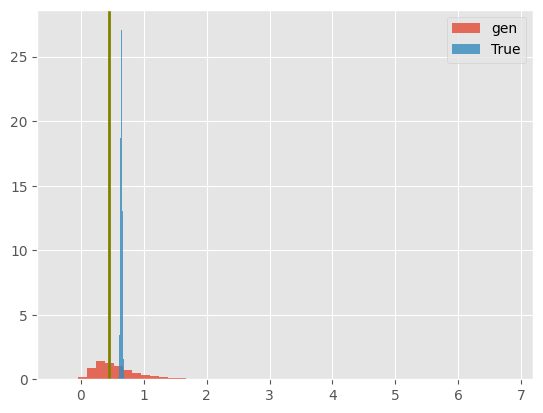

In [115]:
plt.hist(us_gen[:, 0], bins=50, alpha=0.8, density=True, label="gen");
plt.hist(us_true[:, 0], bins=50, alpha=0.8, density=True, label="True");
plt.axvline(u_rare[0], c="olive", linewidth=2)
plt.legend()

In [84]:
seed = 2
n_projections = 2048
swd(
    np.asarray(us_gen),
    us_true,
    a=np.ones(len(us_gen)) / len(us_gen),
    b=np.ones(len(us_true)) / len(us_true),
    n_projections=n_projections,
    seed=seed,
)

np.float64(0.01994092587401751)

In [46]:
us_gen_sub = np.asarray(us_gen)[np.random.choice(100000, (20000,)), :]
us_true_sub = us_true[np.random.choice(100000, (20000,)), :]
gen_ws = np.ones(len(us_gen_sub)) / len(us_gen_sub)
true_ws = np.ones(len(us_true_sub)) / len(us_true_sub)

swd(
    us_gen_sub,
    us_true_sub,
    a=gen_ws,
    b=true_ws,
    n_projections=n_projections,
    seed=seed+8,
)

np.float64(0.012254766943939939)

Doing MCMC

In [4]:
mean = jnp.array([ 1.76380575,  3.21845159, -1.33022676,  2.86776002, -1.56465276,
        1.90740682, -1.04500058,  1.40077561, -0.54798456,  1.25579676,
       -0.23492035,  1.23703067, -0.04610096,  1.26281212,  0.07403253,
        1.28140413,  0.14642627,  1.29951545])
std = jnp.array(
    [3.8370103 , 2.22803335, 6.02701747, 1.93188936, 6.9905162 ,
       1.95442761, 7.35127288, 2.03740099, 7.32107706, 2.17594022,
       7.12427577, 2.30258108, 6.88576505, 2.39143307, 6.64022664,
       2.46501174, 6.42853767, 2.49830229]
)

In [5]:
from jax.scipy.optimize import minimize
from triangular_transport.mcmc.adaptive_mcmc import AdaptiveMCMC
from triangular_transport.mcmc.mala import MALA
# from adap_mcmc import AdaptiveMCMC
from triangular_transport.flows.dataloaders import log_normal_reference_sampler
from lv import LV

# @partial(jit, static_argnums=2)
def alpha(x, w, log_density):
    log_w = log_density(w) #w is in log space
    log_x = log_density(x) #x is in log space
    # print(f"This is the current state: {x}")
    # print(f"This is the proposal: {w}")
    # Don't need proposal densities here bc they end up cancelling out.
    return jnp.minimum(0.0, log_w - log_x)
T = 18
seed = np.random.choice(100000)
no_samples = 100000
u_true = jnp.array([0.83194674, 0.04134147, 1.0823151, 0.03991483]) # TODO: Need to figure out how to get u_true here from a y_obs.
# sigma = jnp.sqrt(0.1).item()
# sigma = jnp.sqrt(0.9).item()
# sigma = 0.1
sigma = 1.0
lv_sampler = LV(
    seed=0,
    no_samples=no_samples,
    prior_sampler=log_normal_reference_sampler,
    likelihood_sampler=log_normal_reference_sampler,
    normalize=False,
    u_true=u_true,
    sigma=sigma,
    dt0=0.1,
    log_y_mean=mean,
    log_y_std=std
)
train_data = lv_sampler.get_target_samples()
ys, us = train_data[:, :T], train_data[:, T:]

In [157]:
vmap_solver = vmap(lv_sampler.solve_lv, in_axes=(None, 0))

In [158]:
sols = vmap_solver(lv_sampler.y0_start, us)
mean = jnp.mean(jnp.log(sols), axis=0).ravel()
mean

Array([ 1.76380575,  3.21845159, -1.33022676,  2.86776002, -1.56465276,
        1.90740682, -1.04500058,  1.40077561, -0.54798456,  1.25579676,
       -0.23492035,  1.23703067, -0.04610096,  1.26281212,  0.07403253,
        1.28140413,  0.14642627,  1.29951545], dtype=float64)

In [159]:
std = jnp.std(jnp.log(sols), axis=0).ravel()
std

Array([3.8370103 , 2.22803335, 6.02701747, 1.93188936, 6.9905162 ,
       1.95442761, 7.35127288, 2.03740099, 7.32107706, 2.17594022,
       7.12427577, 2.30258108, 6.88576505, 2.39143307, 6.64022664,
       2.46501174, 6.42853767, 2.49830229], dtype=float64)

In [163]:
from tqdm.auto import tqdm
yobs = np.log(np.load("true_samps/y_moderate.npy"))  # raw obs -> log space; matches u_moderate
# rng = np.random.RandomState(43)
# yobs = yobs + 0.001 * rng.randn(yobs.shape[0],)
# yobs = np.load("true_samps/y_obs.npy")
# yobs = np.log(ys[64535])
# yobs = np.log(ys[4])

pi = lv_sampler.posterior
log_pi = lv_sampler.log_posterior
@jax.jit
def post(x):
    # Input must be in log space
    return pi(yobs, x)
@jax.jit
def log_post(x):
    # Input must be in log space
    return log_pi(yobs, x)

def neg_post(x):
    # Input must be in log space
    return -log_pi(yobs, x)

# Run BFGS from 5 different starting points and keep the best MAP
n_restarts = 5
init_key = random.key(seed=11)
# x_inits = [jnp.log(u_moderate)]  # first start: known good init
x_inits = []

for i in range(n_restarts):
    init_key, subkey = random.split(init_key)
    x_inits.append(
        random.normal(subkey, shape=(u_dim,)) * lv_sampler.std_prior + lv_sampler.mu_base
    )
# x_inits = np.log(us_gen[np.random.choice(nsamples, size=(n_restarts, ))])

best_val = jnp.inf
best_result = None
for i, x_init in enumerate(tqdm(x_inits)):
    result = minimize(neg_post, x_init, method="BFGS", tol=1e-8)
    val = neg_post(result.x)
    print(f"Init {i}: neg_post = {val:.4f}, exp(x) = {jnp.exp(result.x)}")
    if val < best_val:
        best_val = val
        best_result = result

x0 = best_result.x
print(f"\nBest x0: {jnp.exp(x0)}  (neg_post = {best_val:.4f})")

  0%|          | 0/5 [00:00<?, ?it/s]

Init 0: neg_post = -2.9054, exp(x) = [1.05679794 0.03774632 1.03215046 0.18674402]
Init 1: neg_post = 113.0033, exp(x) = [0.47435938 0.03868951 0.36414235 0.06862367]
Init 2: neg_post = 74.9008, exp(x) = [1.40488051 0.0518456  0.74724083 0.01795513]
Init 3: neg_post = 108.7071, exp(x) = [0.27506119 0.01868414 0.45812203 0.07677304]
Init 4: neg_post = 96.1591, exp(x) = [0.25549565 0.14069362 0.28026858 0.05325379]

Best x0: [1.05679794 0.03774632 1.03215046 0.18674402]  (neg_post = -2.9054)


In [138]:
u_moderate

array([0.578308  , 0.06101701, 0.4618392 , 0.10620669])

In [140]:
nsteps = 5000

def alpha_mala(x, w, transition_kernels, log_density):
    log_kern0, log_kern1 = transition_kernels[0], transition_kernels[1]
    log_prob = log_density(w) + log_kern0 - log_density(x) - log_kern1
    # print(f"This is w: {w}")
    # print(f"This is x: {x}")
    # print(f"This is log_x: {log_density(x)}")
    # print(f"This is log_w: {log_density(w)}")
    # print(f"This is the log prob: {log_prob}")
    prob = jnp.exp(log_prob)
    # print(prob)
    return jnp.minimum(1., prob)

adapt_mcmc = AdaptiveMCMC(
    target_density=post,
    log_density=log_post,
    alpha_function=alpha,
    seed=np.random.choice(1000000),
    train_dim=4,
    steps=nsteps,
    name="Adaptive - Conditional",
    std_err=0.07,
    iter_step_adapt=100,
    cond_no=yobs,
    burn_in=1000,
    # burn_in=1,
    x0=x0,
)
adapt_mcmc.fit(print_every=100, log_update=False)
# mala_mcmc = MALA(
#     target_density=post,
#     log_density=log_post,
#     alpha_function=alpha_mala,
#     seed=2,
#     train_dim=4,
#     steps=5000,
#     step_size=0.000004,
#     name="mala",
#     alpha_kwargs={"log_density": log_post},
#     cond_no=yobs,
#     burn_in=1000,
#     x0=x0,
#     # x0=x_init,
# )
# mala_mcmc.fit(print_every=100)

us_ada = adapt_mcmc.samples
# us_mala = mala_mcmc.samples


  0%|          | 0/6000 [00:00<?, ?it/s]

The acceptance rate is: 0.34
The acceptance rate is: 0.38
The acceptance rate is: 0.38
The acceptance rate is: 0.3525
The acceptance rate is: 0.362
The acceptance rate is: 0.34833333333333333
The acceptance rate is: 0.35428571428571426
The acceptance rate is: 0.35125
The acceptance rate is: 0.3422222222222222
The acceptance rate is: 0.353
The acceptance rate is: 0.3472727272727273
The acceptance rate is: 0.3425
The acceptance rate is: 0.34307692307692306
The acceptance rate is: 0.3492857142857143
The acceptance rate is: 0.346
The acceptance rate is: 0.35
The acceptance rate is: 0.3452941176470588
The acceptance rate is: 0.3477777777777778
The acceptance rate is: 0.35
The acceptance rate is: 0.348
The acceptance rate is: 0.35333333333333333
The acceptance rate is: 0.3522727272727273
The acceptance rate is: 0.35
The acceptance rate is: 0.35
The acceptance rate is: 0.352
The acceptance rate is: 0.3546153846153846
The acceptance rate is: 0.3566666666666667
The acceptance rate is: 0.3546428

In [141]:
np.mean(np.exp(us_ada), axis=0)

array([0.74565362, 0.04815824, 0.45969824, 0.09765682])

In [142]:
u_moderate

array([0.578308  , 0.06101701, 0.4618392 , 0.10620669])

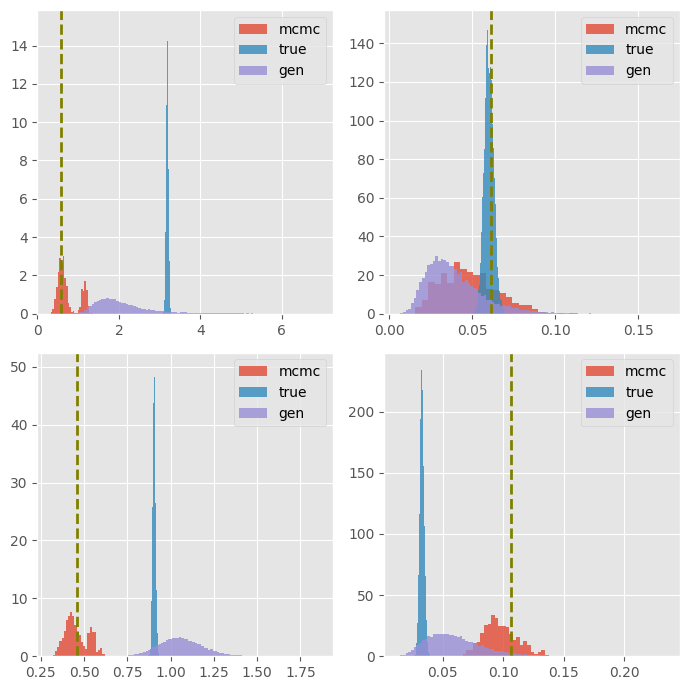

In [153]:
fig, ax = plt.subplots(2,2, figsize=(7,7))

ax[0][0].hist(np.exp(us_ada)[:, 0], bins=25, alpha=0.8, density=True, label="mcmc");
ax[0][0].hist(us_true[:, 0], bins=300, alpha=0.8, density=True, label="true")
ax[0][0].hist(us_gen[:, 0], bins=100, alpha=0.8, density=True, label="gen");
ax[0][0].axvline(u_moderate[0], c="olive", linewidth=2, linestyle="--")
ax[0][0].legend(loc="best")

ax[0][1].hist(np.exp(us_ada)[:, 1], bins=25, alpha=0.8, density=True, label="mcmc");
ax[0][1].hist(us_true[:, 1], bins=300, alpha=0.8, density=True, label="true")
ax[0][1].hist(us_gen[:, 1], bins=100, alpha=0.8, density=True, label="gen");
ax[0][1].axvline(u_moderate[1], c="olive", linewidth=2, linestyle="--")
ax[0][1].legend(loc="best")

ax[1][0].hist(np.exp(us_ada)[:, 2], bins=25, alpha=0.8, density=True, label="mcmc");
ax[1][0].hist(us_true[:, 2], bins=300, alpha=0.8, density=True, label="true")
ax[1][0].hist(us_gen[:, 2], bins=100, alpha=0.8, density=True, label="gen");
ax[1][0].axvline(u_moderate[2], c="olive", linewidth=2, linestyle="--")
ax[1][0].legend(loc="best")

ax[1][1].hist(np.exp(us_ada)[:, 3], bins=25, alpha=0.8, density=True, label="mcmc");
ax[1][1].hist(us_true[:, 3], bins=300, alpha=0.8, density=True, label="true")
ax[1][1].hist(us_gen[:, 3], bins=100, alpha=0.8, density=True, label="gen");
ax[1][1].axvline(u_moderate[3], c="olive", linewidth=2, linestyle="--")
ax[1][1].legend(loc="best")

plt.tight_layout()

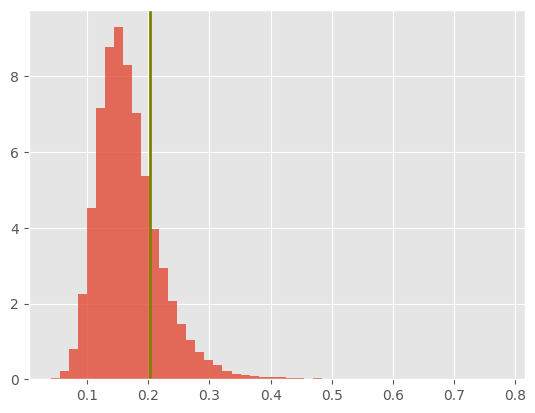

In [23]:
plt.hist(us_gen[:, 3], bins=50, alpha=0.8, density=True);
plt.axvline(u_moderate[3], c="olive", linewidth=2)

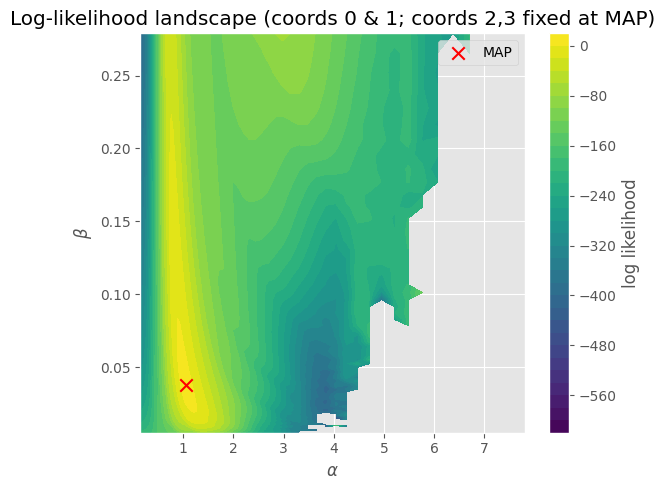

In [164]:

# Plot the likelihood landscape over the first two coordinates (log alpha, log beta)
# Coords 2 and 3 are fixed at the MAP estimate x0

n_grid = 80
x0_center = x0  # MAP in log-space, shape (4,)

coord0_vals = jnp.linspace(x0_center[0] - 2.0, x0_center[0] + 2.0, n_grid)
coord1_vals = jnp.linspace(x0_center[1] - 2.0, x0_center[1] + 2.0, n_grid)

grid0, grid1 = jnp.meshgrid(coord0_vals, coord1_vals)  # each (n_grid, n_grid)

# Build (n_grid^2, 4) array with coords 2 & 3 fixed at MAP
flat0 = grid0.ravel()
flat1 = grid1.ravel()
fixed_tail = jnp.broadcast_to(x0_center[2:], (n_grid * n_grid, 2))
xs_grid = jnp.column_stack([flat0, flat1, fixed_tail])

log_lik_vals = vmap(lambda x: lv_sampler.log_likelihood_pdf(yobs, x))(xs_grid)
log_lik_grid = log_lik_vals.reshape(n_grid, n_grid)

fig, ax = plt.subplots(figsize=(6, 5))
cf = ax.contourf(
    np.exp(grid0), np.exp(grid1),
    log_lik_grid,
    levels=40, cmap="viridis"
)
ax.scatter([np.exp(x0_center[0])], [np.exp(x0_center[1])],
           color="red", marker="x", s=80, label="MAP", zorder=5)
plt.colorbar(cf, ax=ax, label="log likelihood")
ax.set_xlabel(r"$\alpha$")
ax.set_ylabel(r"$\beta$")
ax.set_title("Log-likelihood landscape (coords 0 & 1; coords 2,3 fixed at MAP)")
ax.legend()
plt.tight_layout()
plt.show()
